In [1]:
#customer churn prediction

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE

#Loading Data
df = pd.read_excel("telco/Telco_customer_churn.xlsx")
print(df.shape)

# Drop Irrelevant Columns
drop_cols = ["CustomerID", "Count", "Country", "State", "City","Zip Code", "Lat Long", "Latitude", "Longitude","Churn Value", "Churn Score", "CLTV", "Churn Reason"]
df.drop(columns=drop_cols, inplace=True, errors="ignore")

# Fix Target Column
# Churn Label is "Yes"/"No" - convert to 1/0
df["Churn Label"] = df["Churn Label"].map({"Yes": 1, "No": 0})

#Encode all remaining object columns 
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Ensure all are numeric
df = df.apply(pd.to_numeric, errors="coerce")
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

#Features and Target
feature_cols = [c for c in df.columns if c != "Churn Label"]
X = np.nan_to_num(df[feature_cols].astype(float).values)
y = df["Churn Label"].astype(int).values

print("Churn distribution before SMOTE:", np.bincount(y))

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Churn distribution after SMOTE:", np.bincount(y_train_res))

#Scale Features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

#Logistic Regression 
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_res)
lr_preds = lr.predict(X_test_scaled)

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))

lr_cv = cross_val_score(lr, X, y, cv=5, scoring="roc_auc")
print("LR Cross-Val ROC-AUC:", lr_cv.mean().round(4), "±", lr_cv.std().round(4))

#Decision Tree with GridSearch
print("\nRunning GridSearch for Decision Tree...")
dt_params = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=3, scoring="roc_auc", verbose=1
)
dt_grid.fit(X_train_res, y_train_res)
print("Best Decision Tree Params:", dt_grid.best_params_)

dt_model = dt_grid.best_estimator_
dt_preds = dt_model.predict(X_test)

print("\n--- Decision Tree Results ---")
print(classification_report(y_test, dt_preds))
print("ROC-AUC:", roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1]))

dt_cv = cross_val_score(dt_model, X, y, cv=5, scoring="roc_auc")
print("DT Cross-Val ROC-AUC:", dt_cv.mean().round(4), "±", dt_cv.std().round(4))

#Neural Network 
print("\nTraining Neural Network...")
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=0.001,
    max_iter=300,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train_res)
nn_preds = nn_model.predict(X_test_scaled)

print("\n--- Neural Network Results ---")
print(classification_report(y_test, nn_preds))
print("ROC-AUC:", roc_auc_score(y_test, nn_model.predict_proba(X_test_scaled)[:, 1]))

nn_cv = cross_val_score(nn_model, X, y, cv=5, scoring="roc_auc")
print("NN Cross-Val ROC-AUC:", nn_cv.mean().round(4), "±", nn_cv.std().round(4))

#Model Comparison
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Neural Network"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, nn_model.predict_proba(X_test_scaled)[:, 1])
    ],
    "CV ROC-AUC Mean": [lr_cv.mean().round(4), dt_cv.mean().round(4), nn_cv.mean().round(4)],
    "CV Std": [lr_cv.std().round(4), dt_cv.std().round(4), nn_cv.std().round(4)]
})
print("\n--- Model Comparison ---")
print(results.sort_values("ROC-AUC", ascending=False))

(7043, 33)
Churn distribution before SMOTE: [5174 1869]
Churn distribution after SMOTE: [4139 4139]

Training Logistic Regression...

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8442532744323026
LR Cross-Val ROC-AUC: 0.8548 ± 0.0101

Running GridSearch for Decision Tree...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}

--- Decision Tree Results ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.58      0.57       374

    accuracy                           0.77   

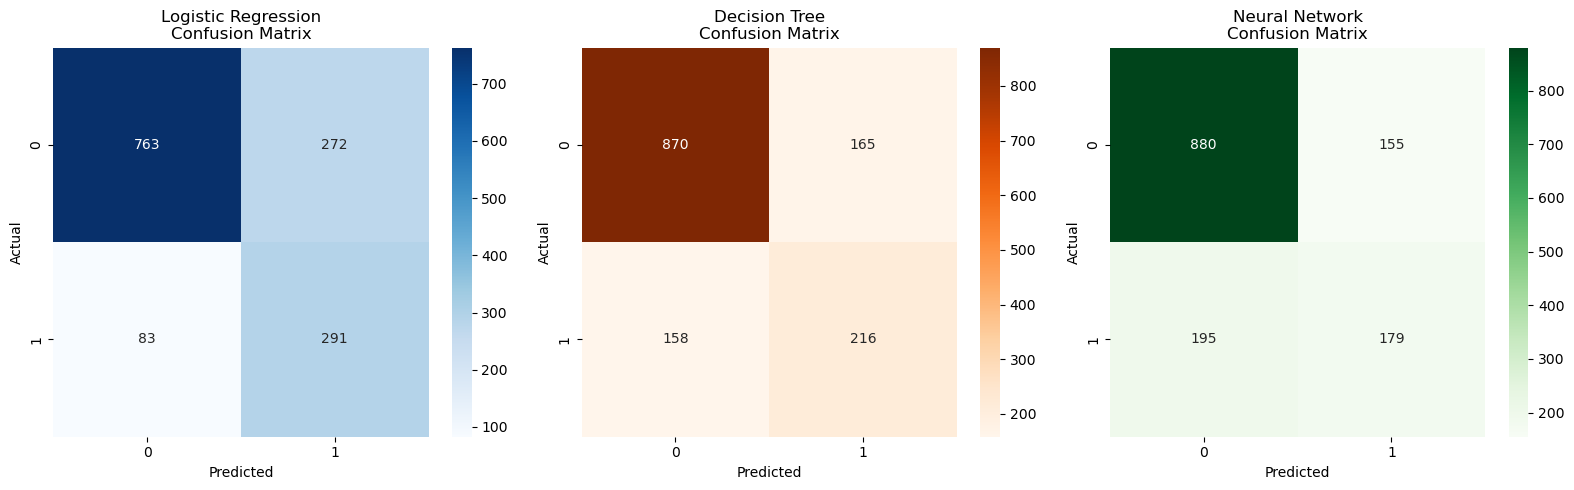

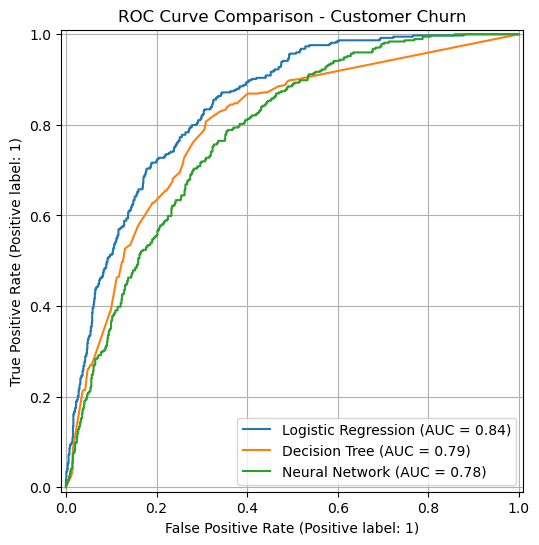

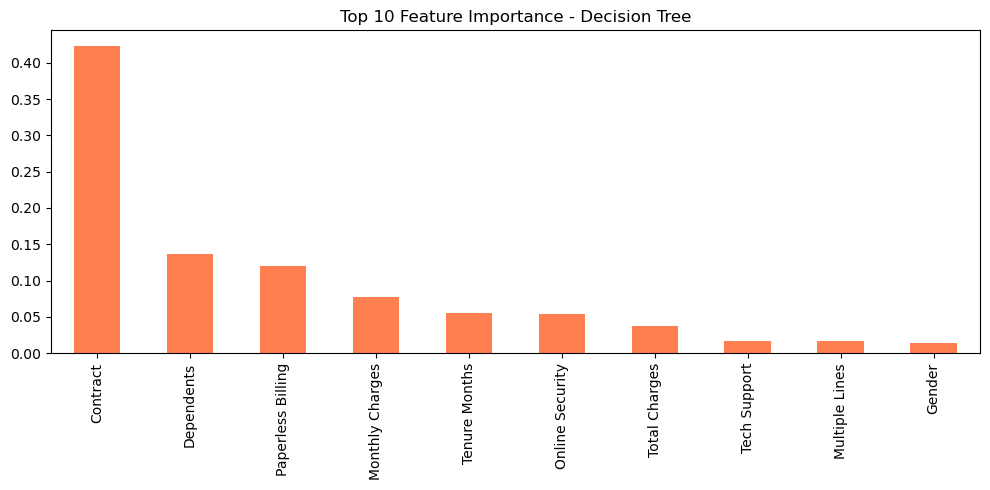

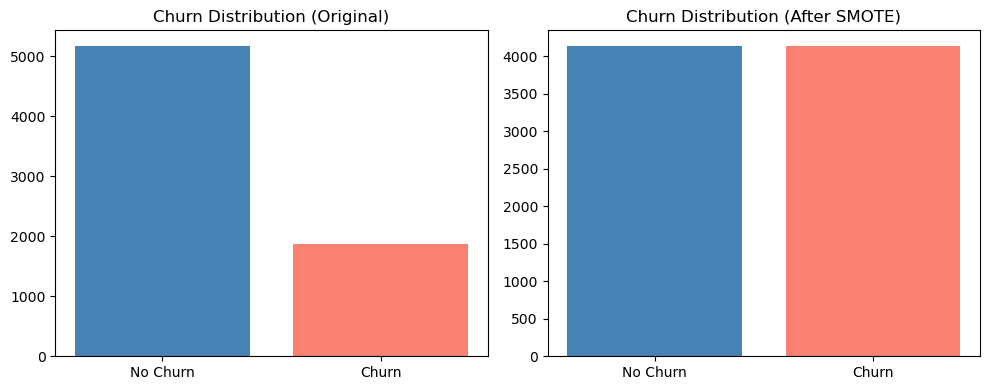

In [3]:
#Confusion Matrices 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, preds, title, cmap in zip(
    axes,
    [lr_preds, dt_preds, nn_preds],
    ["Logistic Regression", "Decision Tree", "Neural Network"],
    ["Blues", "Oranges", "Greens"]
):
    sns.heatmap(confusion_matrix(y_test, preds),
                annot=True, fmt="d", cmap=cmap, ax=ax)
    ax.set_title(f"{title}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

#ROC Curve 
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(nn_model, X_test_scaled, y_test, ax=ax, name="Neural Network")
plt.title("ROC Curve Comparison - Customer Churn")
plt.grid(True)
plt.show()

#Feature Importance
feat_imp = pd.Series(
    dt_model.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(10)
feat_imp.plot(kind="bar", figsize=(10, 5), color="coral",
              title="Top 10 Feature Importance - Decision Tree")
plt.tight_layout()
plt.show()

#Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["No Churn", "Churn"], np.bincount(y),
            color=["steelblue", "salmon"])
axes[0].set_title("Churn Distribution (Original)")
axes[1].bar(["No Churn", "Churn"], np.bincount(y_train_res),
            color=["steelblue", "salmon"])
axes[1].set_title("Churn Distribution (After SMOTE)")
plt.tight_layout()
plt.show()